In [1]:
PRODUCTION_QUALITY = False

import ipdb
import json
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import scienceplots
import pandas as pd
import os
import re
import warnings

from labellines import labelLines

plt.style.use(['science', 'bright'])

dpi = 300 if PRODUCTION_QUALITY else 100

plt.rcParams.update({
    'text.usetex': True,
    'font.size': 12,
    'font.family': 'lmodern',
    'savefig.bbox': 'tight',
    'savefig.format': 'pdf',
    'figure.constrained_layout.use': True,
    'legend.frameon': True,
    'savefig.dpi': dpi,
})

EXPERIMENT_BASE='05-signal-to-noise-ratio-for-batch-size-variation'

# width of the thesis in points
WIDTH = 441.01775
OUTPUT_DIR=f'../{EXPERIMENT_BASE}/images'

# Beamer 16:9
#WIDTH=455.24408
#OUTPUT_DIR='/home/arehn/presentations/meeting-20241201/images/'

os.makedirs(OUTPUT_DIR, exist_ok=True) # make sure it exists

# image saving format
IMG_FORMAT = 'pdf'

# Mapping of full model names to abbreviations
MODEL_NAME_MAP = {
    'vit_base_patch16_224.augreg_in21k': 'ViT',
    'resnetv2_50x1_bit.goog_in21k': 'ResNetV2',
}

In [2]:
def set_size(width_pt, fraction=1, subplots=(1, 1), y_scale=False):
    """Set figure dimensions to avoid scaling in LaTeX.

    Parameters
    ----------
    width: float or string
            Document width in points, or string of predined document type
    fraction: float, optional
            Fraction of the width which you wish the figure to occupy
    subplots: array-like, optional
            The number of rows and columns of subplots.
    Returns
    -------
    fig_dim: tuple
            Dimensions of figure in inches
    """
    # Width of figure (in pts)
    fig_width_pt = width_pt * fraction
    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Golden ratio to set aesthetic figure height
    # https://disq.us/p/2940ij3
    golden_ratio = (5**.5 - 1) / 2

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt

    fig_height_in = fig_width_in * golden_ratio * (subplots[0] / subplots[1])
    
    if y_scale:
        fig_height_in = fig_height_in * y_scale

    return (fig_width_in, fig_height_in)

In [3]:
def get_figure(subplots, fraction=1.0, y_scale=False):
    figsize = set_size(WIDTH, fraction=fraction, subplots=subplots, y_scale=y_scale)
    fig, axes = plt.subplots(subplots[0], subplots[1], figsize=figsize, constrained_layout=True)

    return fig, axes

In [4]:
def read_json_data(file_path):
    with open(file_path, 'r') as file:
        return json.load(file)

In [5]:
def prepare_experiment_data(data):
    records = []
    for experiment_id, experiment_details in data.items():
        # Extracting values from the JSON structure
        seed = subset_size = experiment_details['configuration']['seed']
        subset_size = experiment_details['configuration']['subset_size']
        batch_size = experiment_details['hyperparameters']['batch_size']
        
        # Handling the full batch size case
        if batch_size == -1:
            full_batch_size = 5000 if subset_size == 0.1 else 50000
            batch_size = full_batch_size
            
        learning_rate = experiment_details['hyperparameters']['learning_rate']
        max_grad_norm = experiment_details['hyperparameters']['max_grad_norm']
        epochs = experiment_details['hyperparameters']['epochs']

        record = {
            'experiment_id': experiment_id,
            'model_name': experiment_details['configuration']['model_name'],
            'dataset_name': experiment_details['configuration']['dataset_name'],
            'subset_size': subset_size,
            'epsilon': experiment_details['hyperparameters']['target_epsilon'],
            'batch_size': batch_size,
            #'accuracy': float(experiment_details['best_value']),
            'learning_rate': learning_rate,
            'max_grad_norm': max_grad_norm,
            'epochs': epochs,
            'seed': seed,
        }
        records.append(record)

    return pd.DataFrame(records)

In [6]:
def prepare_snr_data(data):
    snr_records = []
    for experiment_id, experiment_details in data.items():
        snr_data = experiment_details.get('signal_to_noise_ratio', [])
        for snr_record in snr_data:
            snr_record['experiment_id'] = experiment_id
            snr_record['Step'] = int(snr_record['Step'])
            snr_record['Grad_Norm'] = float(snr_record['Grad_Norm'])
            snr_record['Noise_Norm'] = float(snr_record['Noise_Norm'])
            snr_record['SNR'] = float(snr_record['SNR'])
            snr_records.append(snr_record)
    
    return pd.DataFrame(snr_records)

In [8]:
file_path = '../05-signal-to-noise-ratio-for-batch-size-variation/processed-data/aggregated_data.json'
json_data = read_json_data(file_path)

experiments_df = prepare_experiment_data(json_data)
snr_df = prepare_snr_data(json_data)

merged_df = pd.merge(snr_df, experiments_df, on='experiment_id')

# Plots start here

In [24]:
def plot_snr_trends(merged_df, output_dir=None):
    merged_df.sort_values(['model_name', 'dataset_name', 'subset_size', 'epsilon', 'batch_size'], inplace=True)
    groups = merged_df.groupby(['model_name', 'dataset_name', 'subset_size', 'epsilon'])

    for (model, dataset, subset, epsilon), group in groups:
        fig, ax = get_figure((1,1))

        model_name = MODEL_NAME_MAP.get(model, model)

        grouped_by_batch_size = group.groupby('batch_size')
        for batch_size, batch_group in grouped_by_batch_size:
            batch_group = batch_group.sort_values(by='Step')
            
            steps = batch_group['Step']
            snr_values = batch_group['SNR']
            
            ax.scatter(steps, snr_values, label=f'Batch Size {batch_size}', marker='o', s=5)
        
        ax.set_title(f'SNR Trends for {model_name} on {dataset}, Subset {int(subset*100)}\%, $\epsilon={epsilon}$')
        ax.set_xlabel('Step')
        ax.set_ylabel('SNR')
        ax.legend()
        ax.grid(True)

        if output_dir:
            filename = f'SNR_trends_{model_name}_{dataset}_subset{int(subset*100)}_epsilon{epsilon}.png'
            plt.savefig(os.path.join(output_dir, filename))
        
        plt.show()

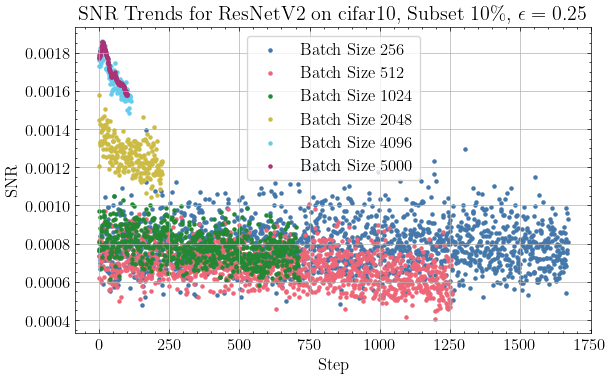

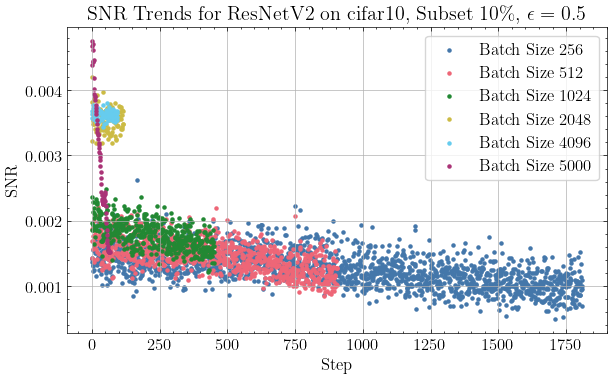

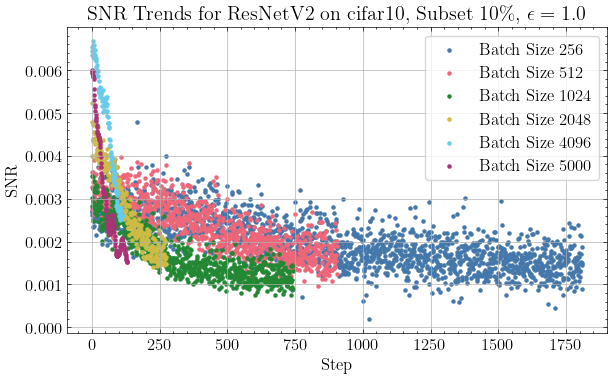

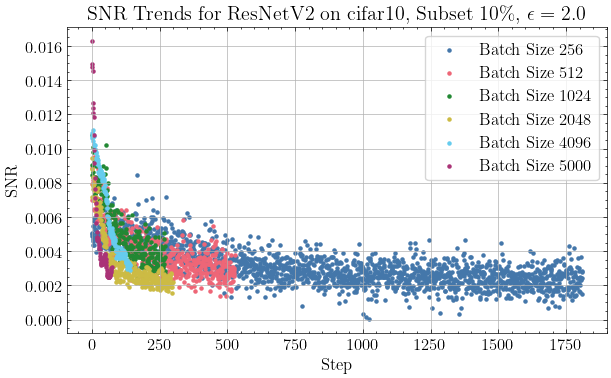

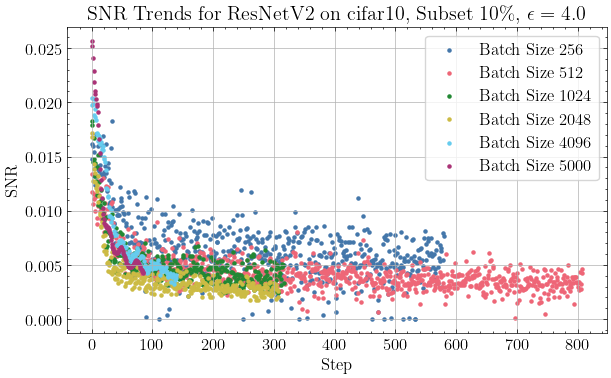

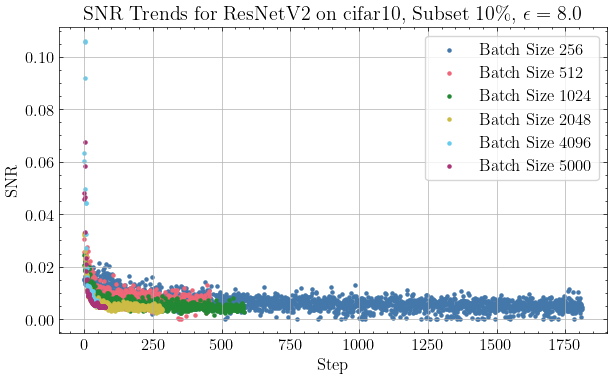

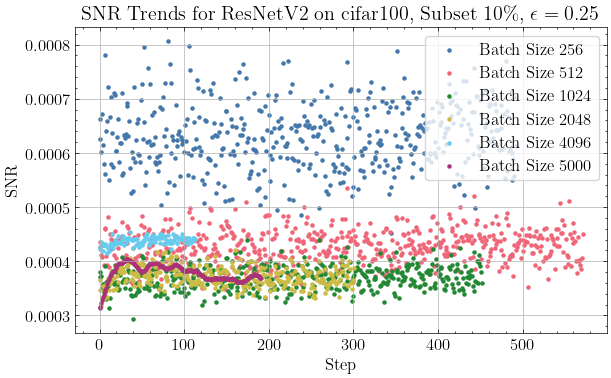

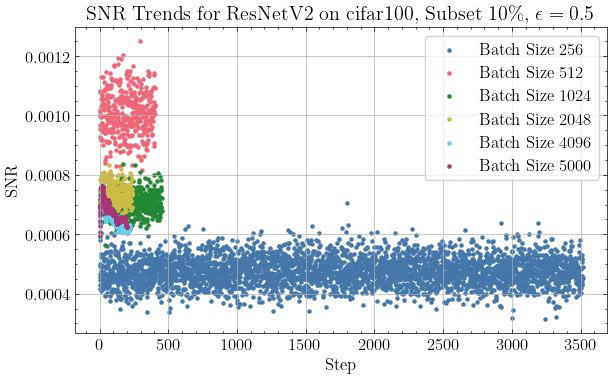

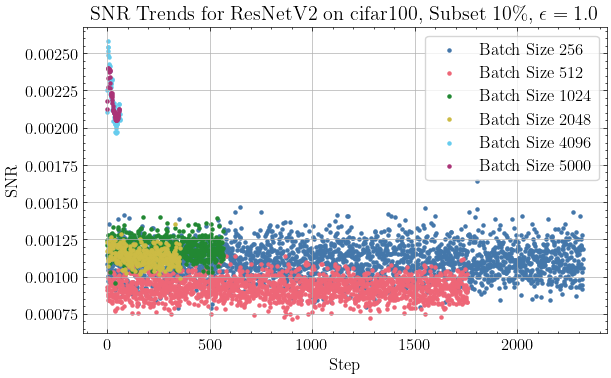

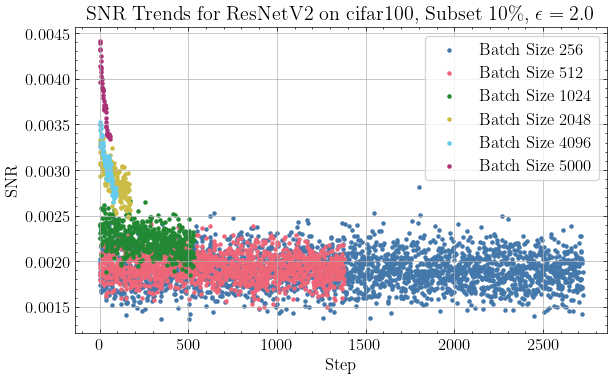

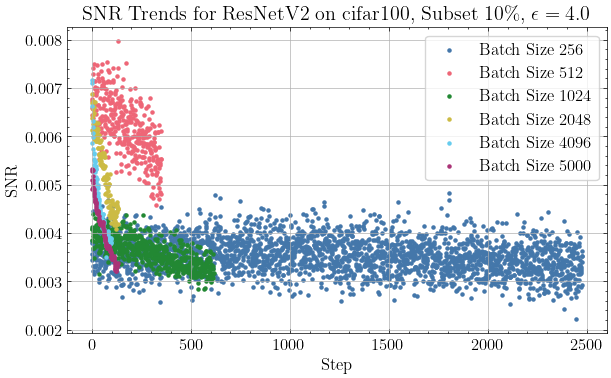

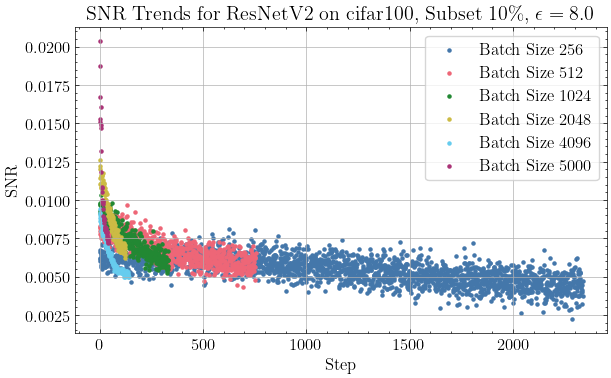

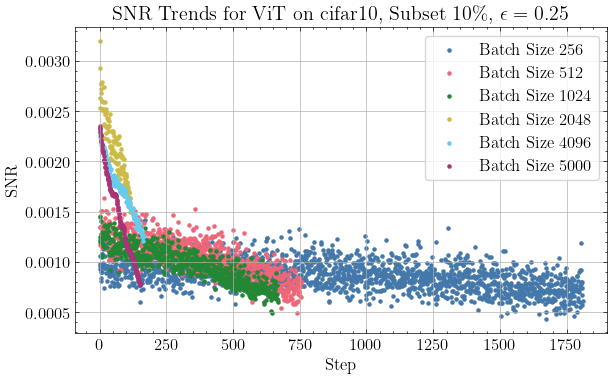

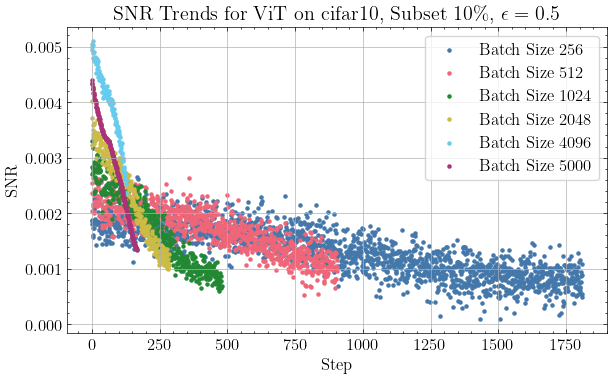

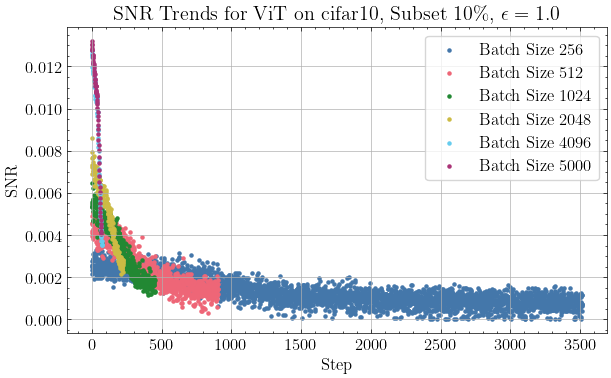

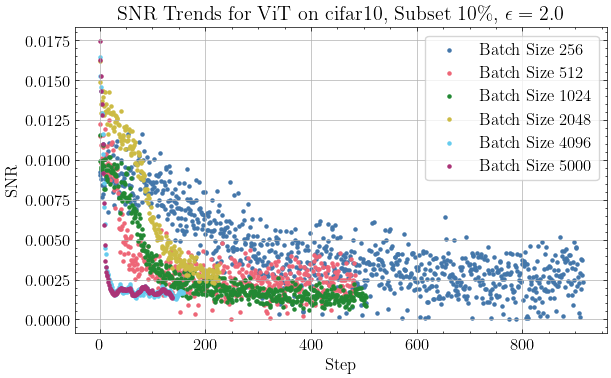

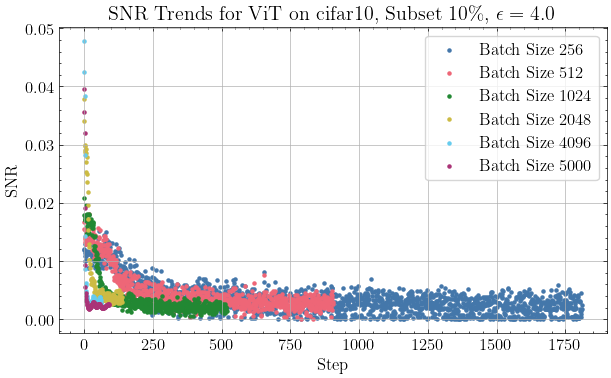

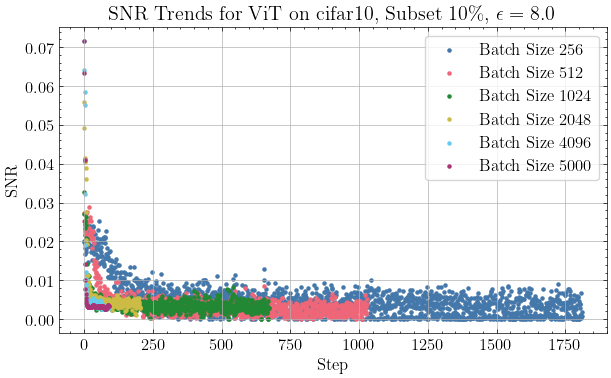

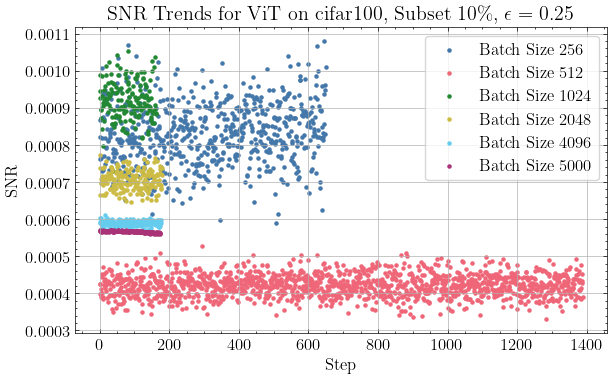

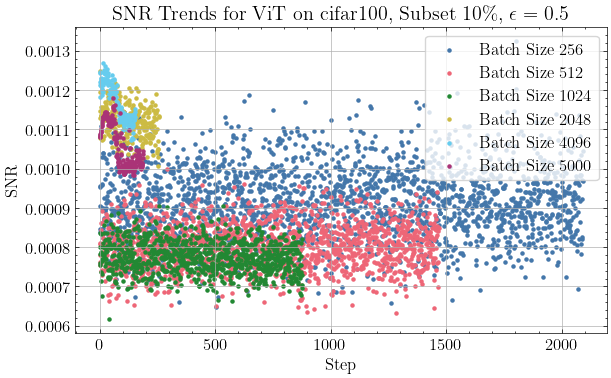

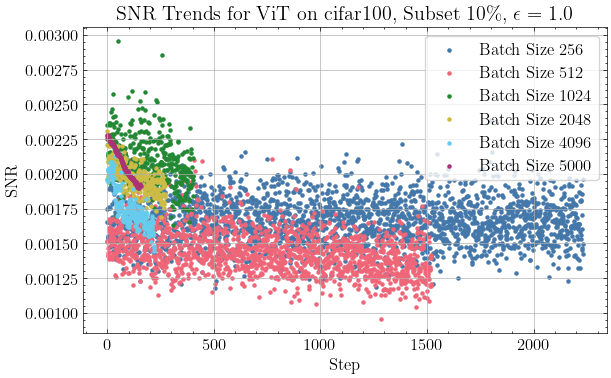

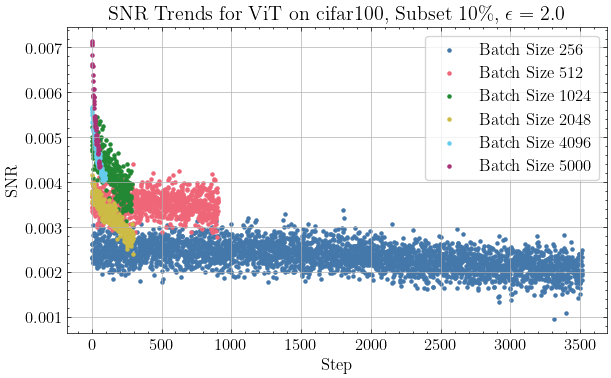

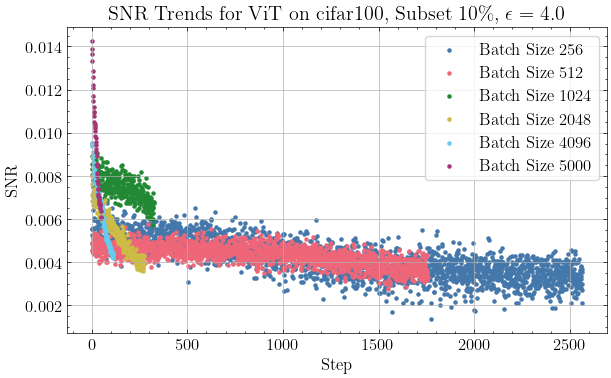

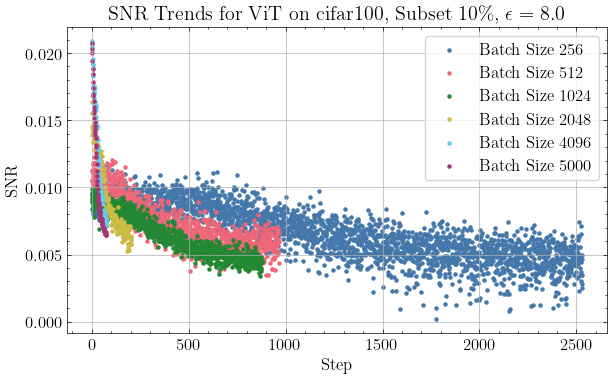

In [25]:
plot_snr_trends(merged_df, output_dir=OUTPUT_DIR)

# Testing

In [ ]:
experiment_id_to_plot = 'resnetv2_50x1_bit.goog_in21k_cifar10_Subset0.1_Epsilon1_BatchSize4096'
data_to_plot = snr_df[snr_df['experiment_id'] == experiment_id_to_plot]

fig, ax = get_figure((1,1))
ax.plot(data_to_plot['Step'], data_to_plot['SNR'], marker='o')
ax.set_title('SNR Trend Over Steps')
ax.set_xlabel('Step')
ax.set_ylabel('SNR')
ax.grid(True)
plt.show()